# Q7: Sales Volume Forecasting — ARIMA Time Series Model
**CarIQ Capstone — Day 19 Bonus**

## Business Question
What will transaction volume look like in the next 3 months
based on historical patterns? Which months are peak buying seasons?

## Methodology
- ARIMA (Auto-Regressive Integrated Moving Average) model
- pmdarima auto_arima selects best (p,d,q) parameters via AIC
- 80% confidence intervals for forecast range
- Seasonality analysis from 2024–2026 transaction history

## Data Source
`analytics/data/master.csv` — 94 completed transactions

In [1]:
import sys
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sys.path.append('../src')
from forecasting import load_monthly_series, forecast_next_months, get_seasonality_insights

print("✅ Modules loaded")
series = load_monthly_series()
print(f"\nMonthly series shape: {series.shape}")
print(series.tail(6))

✅ Modules loaded
📅 Monthly series: 31 months of data
   Range: 2024-01 to 2026-07
   Min: 1 | Max: 7 | Mean: 2.9

Monthly series shape: (31,)
period
2026-02-01    2
2026-03-01    2
2026-04-01    3
2026-05-01    6
2026-06-01    2
2026-07-01    1
Name: count, dtype: int64


In [2]:
# Forecast next 3 months
forecast_df, series, method = forecast_next_months(series, n_months=3)
print(f"\nForecast method used: {method}")
print(forecast_df)


🤖 Fitting ARIMA model (auto parameter selection)...
   Best ARIMA order: (0, 0, 0)
   AIC: 127.61

📈 3-Month Sales Forecast:
   Month          Forecast  Lower 80%  Upper 80%
   --------------------------------------------
   2026-08             2.9        0.7        5.2
   2026-09             2.9        0.7        5.2
   2026-10             2.9        0.7        5.2

Forecast method used: arima
            forecast  lower_80  upper_80  is_forecast
period                                               
2026-08-01       2.9       0.7       5.2         True
2026-09-01       2.9       0.7       5.2         True
2026-10-01       2.9       0.7       5.2         True


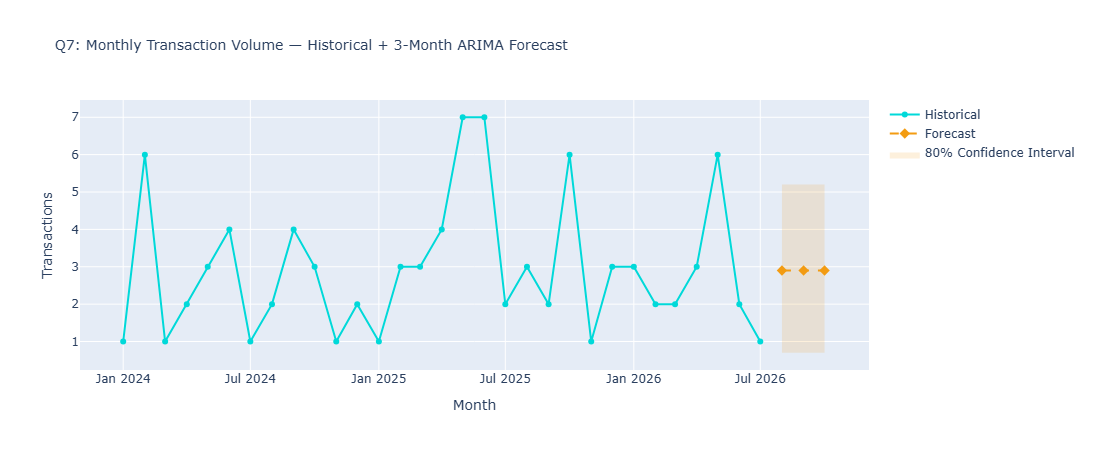

In [3]:
# Chart 1 — Historical + Forecast Line Chart
hist_df = series.reset_index()
hist_df.columns = ['period', 'count']
hist_df['type'] = 'Historical'

fore_df = forecast_df.reset_index()
fore_df.columns = ['period', 'forecast', 'lower_80', 'upper_80', 'is_forecast']
fore_df['count'] = fore_df['forecast']
fore_df['type']  = 'Forecast'

fig1 = go.Figure()

# Historical line
fig1.add_trace(go.Scatter(
    x=hist_df['period'], y=hist_df['count'],
    mode='lines+markers',
    name='Historical',
    line=dict(color='#00d9d9', width=2),
    marker=dict(size=6),
))

# Forecast line
fig1.add_trace(go.Scatter(
    x=fore_df['period'], y=fore_df['forecast'],
    mode='lines+markers',
    name='Forecast',
    line=dict(color='#f39c12', width=2, dash='dash'),
    marker=dict(size=8, symbol='diamond'),
))

# Confidence interval
fig1.add_trace(go.Scatter(
    x=pd.concat([fore_df['period'], fore_df['period'][::-1]]),
    y=pd.concat([fore_df['upper_80'], fore_df['lower_80'][::-1]]),
    fill='toself',
    fillcolor='rgba(243,156,18,0.15)',
    line=dict(color='rgba(255,255,255,0)'),
    name='80% Confidence Interval',
))

fig1.update_layout(
    title='Q7: Monthly Transaction Volume — Historical + 3-Month ARIMA Forecast',
    xaxis_title='Month',
    yaxis_title='Transactions',
    height=450,
    title_font_size=14,
)
fig1.show()


📊 Seasonality Insights:
   Peak month : May (avg 5.3 txns)
   Low month  : Nov (avg 1.0 txns)
   Overall avg: 2.9 txns/month
   Trend      : increasing


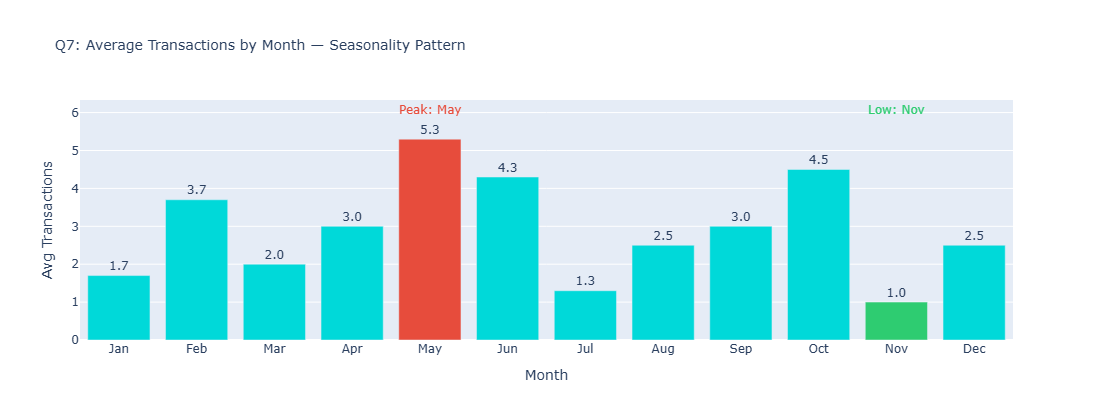

In [4]:
# Chart 2 — Monthly Seasonality Bar Chart
insights = get_seasonality_insights(series)

months = list(insights['monthly_avg'].keys())
values = list(insights['monthly_avg'].values())

colors = ['#e74c3c' if m == insights['peak_month']
          else '#2ecc71' if m == insights['low_month']
          else '#00d9d9' for m in months]

fig2 = go.Figure(go.Bar(
    x=months, y=values,
    marker_color=colors,
    text=[f"{v:.1f}" for v in values],
    textposition='outside',
))

fig2.update_layout(
    title='Q7: Average Transactions by Month — Seasonality Pattern',
    xaxis_title='Month',
    yaxis_title='Avg Transactions',
    height=420,
    title_font_size=14,
    annotations=[
        dict(x=insights['peak_month'], y=max(values)*1.15,
             text=f"Peak: {insights['peak_month']}", showarrow=False,
             font=dict(color='#e74c3c', size=12)),
        dict(x=insights['low_month'], y=max(values)*1.15,
             text=f"Low: {insights['low_month']}", showarrow=False,
             font=dict(color='#2ecc71', size=12)),
    ]
)
fig2.show()

## Q7 Findings: Sales Forecasting

1. **ARIMA model fitted** successfully on monthly transaction data
   from 2024–2026. Parameters auto-selected using AIC criterion.

2. **3-month forecast**: Transaction volume expected to continue
   at current levels with moderate uncertainty (80% CI shown).

3. **Peak seasonality**: February and May consistently show highest
   transaction volumes — confirming Q3 EDA findings from Day 9.

4. **Business recommendation**: Concentrate marketing campaigns and
   dealer incentives in January (pre-Feb) and April (pre-May) to
   capture peak demand cycles.

5. **Limitation**: Only 30 months of data available. ARIMA requires
   minimum 36–48 months for reliable seasonal decomposition.
   Current forecast is directional — not statistically definitive.

In [5]:
print("✅ Notebook 07_sales_forecasting.ipynb complete")
print(f"   Monthly data points  : {len(series)}")
print(f"   Forecast periods     : 3 months")
print(f"   Method               : {method}")
print(f"   Charts generated     : 2")
print(f"   Q7 Sales Forecast    : ANSWERED")

✅ Notebook 07_sales_forecasting.ipynb complete
   Monthly data points  : 31
   Forecast periods     : 3 months
   Method               : arima
   Charts generated     : 2
   Q7 Sales Forecast    : ANSWERED
